# Irrigation Prediction Model


In [24]:
import pandas as pd
import numpy as np 
import joblib
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print("Target: Achieve 80% accuracy with Optimized Random Forest")

Libraries imported successfully!
Target: Achieve 80% accuracy with Optimized Random Forest


## Data Loading and Analysis

In [25]:
# Load the dataset
df = pd.read_csv('irrigation_prediction.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nTarget distribution: {df['Irrigation_Need'].value_counts()}")
print(f"\nTarget percentages:")
print(df['Irrigation_Need'].value_counts(normalize=True) * 100)

# Create binary target: Low = 0, Medium/High = 1 (irrigation needed)
df['Irrigation_Binary'] = (df['Irrigation_Need'] != 'Low').astype(int)
print(f"\nBinary target distribution:")
print(df['Irrigation_Binary'].value_counts())
print(f"Class balance: {df['Irrigation_Binary'].value_counts(normalize=True) * 100}")

Dataset shape: (10000, 20)

Target distribution: Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

Target percentages:
Irrigation_Need
Low       58.64
Medium    38.00
High       3.36
Name: proportion, dtype: float64

Binary target distribution:
Irrigation_Binary
0    5864
1    4136
Name: count, dtype: int64
Class balance: Irrigation_Binary
0    58.64
1    41.36
Name: proportion, dtype: float64


## Feature Engineering


In [26]:
def create_advanced_features(df):
    """Create advanced agricultural features for irrigation prediction"""
    df_enhanced = df.copy()
    
    # Core sensor values
    temp = df['Temperature_C']
    humidity = df['Humidity'] 
    moisture = df['Soil_Moisture']
    
    # === STRESS INDICATORS ===
    # Temperature stress zones (based on agricultural research)
    df_enhanced['extreme_heat'] = (temp > 40).astype(int)
    df_enhanced['heat_stress'] = np.maximum(0, temp - 35) / 10
    df_enhanced['cold_stress'] = np.maximum(0, 20 - temp) / 20
    df_enhanced['optimal_temp'] = ((temp >= 20) & (temp <= 30)).astype(int)
    
    # Moisture stress with non-linear scaling
    df_enhanced['severe_drought'] = (moisture < 20).astype(int)
    df_enhanced['moisture_stress'] = np.maximum(0, 40 - moisture) / 40
    df_enhanced['moisture_stress_squared'] = df_enhanced['moisture_stress'] ** 2
    df_enhanced['optimal_moisture'] = ((moisture >= 40) & (moisture <= 70)).astype(int)
    
    # Humidity-based evaporation and stress
    df_enhanced['low_humidity'] = (humidity < 40).astype(int)
    df_enhanced['high_humidity'] = (humidity > 80).astype(int)
    df_enhanced['humidity_stress'] = np.abs(humidity - 60) / 60
    
    # === INTERACTION FEATURES ===
    # Evapotranspiration approximation
    df_enhanced['et_factor'] = temp * (1 - humidity/100) * np.maximum(0, 1 - moisture/100)
    
    # Water balance indicators
    df_enhanced['water_deficit'] = np.maximum(0, (temp/25) * (1 - humidity/100) - moisture/100)
    df_enhanced['irrigation_urgency'] = df_enhanced['water_deficit'] * (1 + df_enhanced['heat_stress'])
    
    # Crop stress combinations
    df_enhanced['total_stress'] = (
        df_enhanced['heat_stress'] + 
        df_enhanced['moisture_stress'] + 
        df_enhanced['humidity_stress']
    ) / 3
    
    # Environmental comfort score
    df_enhanced['comfort_score'] = (
        df_enhanced['optimal_temp'] + 
        df_enhanced['optimal_moisture'] + 
        ((humidity >= 50) & (humidity <= 70)).astype(int)
    ) / 3
    
    # === COMPLEX RATIOS ===
    df_enhanced['water_supply_demand'] = moisture / (temp + 1)
    df_enhanced['humidity_temp_ratio'] = humidity / (temp + 1)
    
    # Polynomial features for non-linear relationships
    df_enhanced['temp_squared'] = temp ** 2
    df_enhanced['moisture_squared'] = moisture ** 2
    df_enhanced['temp_moisture_interaction'] = temp * moisture / 1000
    
    # === DOMAIN KNOWLEDGE FEATURES ===
    # Seasonal water needs (Indian agriculture)
    season_water_need = {'Kharif': 3, 'Rabi': 2, 'Zaid': 1}
    df_enhanced['season_water_need'] = df['Season'].map(season_water_need)
    
    # Crop water requirements
    crop_water_need = {
        'Rice': 4, 'Sugarcane': 4, 'Cotton': 3, 
        'Maize': 2, 'Wheat': 2, 'Potato': 1
    }
    df_enhanced['crop_water_need'] = df['Crop_Type'].map(crop_water_need)
    
    # Regional water stress (Indian regions)
    region_stress = {'West': 3, 'South': 2, 'Central': 2, 'North': 1, 'East': 1}
    df_enhanced['region_stress'] = df['Region'].map(region_stress)
    
    # === TIME-BASED FEATURES ===
    np.random.seed(42)  # For reproducibility
    # Days since rain (simulated based on rainfall data)
    df_enhanced['days_since_rain'] = np.where(
        df['Rainfall_mm'] > 50, 
        np.random.randint(0, 2, len(df)),
        np.where(
            df['Rainfall_mm'] > 10,
            np.random.randint(2, 5, len(df)),
            np.random.randint(5, 20, len(df))
        )
    )
    
    # Growth stage water needs
    growth_stage_need = {
        'Sowing': 2, 'Vegetative': 3, 'Flowering': 4, 
        'Fruiting': 3, 'Harvest': 1
    }
    df_enhanced['growth_stage_need'] = df['Crop_Growth_Stage'].map(growth_stage_need)
    
    # Field size category
    df_enhanced['field_size_cat'] = pd.cut(
        df['Field_Area_hectare'], 
        bins=[0, 2, 8, float('inf')], 
        labels=[1, 2, 3]
    ).astype(int)
    
    print(f"Advanced features created: {df_enhanced.shape[1] - df.shape[1]} new features")
    return df_enhanced

# Create enhanced dataset
df_enhanced = create_advanced_features(df)
print(f"\nOriginal features: {df.shape[1]}")
print(f"Enhanced features: {df_enhanced.shape[1]}")

Advanced features created: 27 new features

Original features: 21
Enhanced features: 48


## Data Preprocessing and Feature Selection

In [27]:
# Define feature groups
base_features = ['Humidity', 'Soil_Moisture', 'Temperature_C']
stress_features = ['extreme_heat', 'heat_stress', 'cold_stress', 'optimal_temp',
                  'severe_drought', 'moisture_stress', 'moisture_stress_squared', 'optimal_moisture',
                  'low_humidity', 'high_humidity', 'humidity_stress']
interaction_features = ['et_factor', 'water_deficit', 'irrigation_urgency', 'total_stress', 
                       'comfort_score', 'water_supply_demand', 'humidity_temp_ratio']
polynomial_features = ['temp_squared', 'moisture_squared', 'temp_moisture_interaction']
domain_features = ['season_water_need', 'crop_water_need', 'region_stress', 
                  'days_since_rain', 'growth_stage_need', 'field_size_cat']

# All numeric features
all_numeric_features = (
    base_features + stress_features + interaction_features + 
    polynomial_features + domain_features
)

print(f"Total numeric features: {len(all_numeric_features)}")

# Encode categorical features
df_encoded = df_enhanced.copy()

# One-hot encode crop type
crop_encoder = OneHotEncoder(sparse_output=False, drop='first')
crop_encoded = crop_encoder.fit_transform(df_encoded[['Crop_Type']])
crop_columns = [f'Crop_{cat}' for cat in crop_encoder.categories_[0][1:]]
crop_df = pd.DataFrame(crop_encoded, columns=crop_columns, index=df_encoded.index)
df_encoded = pd.concat([df_encoded, crop_df], axis=1)

# Label encode season and region
season_encoder = LabelEncoder()
region_encoder = LabelEncoder()
df_encoded['Season_encoded'] = season_encoder.fit_transform(df_encoded['Season'])
df_encoded['Region_encoded'] = region_encoder.fit_transform(df_encoded['Region'])

# Final feature set
final_features = all_numeric_features + ['Season_encoded', 'Region_encoded'] + crop_columns

print(f"Final feature count: {len(final_features)}")

# Prepare data
X = df_encoded[final_features]
y = df_encoded['Irrigation_Binary']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Class distribution: {y.value_counts()}")

Total numeric features: 30
Final feature count: 37

Feature matrix shape: (10000, 37)
Class distribution: Irrigation_Binary
0    5864
1    4136
Name: count, dtype: int64


In [28]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# Feature selection - Select top 20 features
print("\n=== FEATURE SELECTION ===")
selector = SelectKBest(f_classif, k=20)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

selected_features = X.columns[selector.get_support()]
print(f"Selected {len(selected_features)} best features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i:2d}. {feature}")

# Apply SMOTE to training data
print("\n=== APPLYING SMOTE FOR CLASS BALANCE ===")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_selected, y_train)

print(f"After SMOTE: {X_train_smote.shape}")
print(f"Class balance: {pd.Series(y_train_smote).value_counts()}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test_selected)

print(f"Final training shape: {X_train_scaled.shape}")

Training set: (8000, 37)
Test set: (2000, 37)

=== FEATURE SELECTION ===
Selected 20 best features:
 1. Soil_Moisture
 2. Temperature_C
 3. heat_stress
 4. cold_stress
 5. optimal_temp
 6. severe_drought
 7. moisture_stress
 8. moisture_stress_squared
 9. optimal_moisture
10. et_factor
11. water_deficit
12. irrigation_urgency
13. total_stress
14. comfort_score
15. water_supply_demand
16. humidity_temp_ratio
17. temp_squared
18. moisture_squared
19. temp_moisture_interaction
20. growth_stage_need

=== APPLYING SMOTE FOR CLASS BALANCE ===
After SMOTE: (9382, 20)
Class balance: Irrigation_Binary
0    4691
1    4691
Name: count, dtype: int64
Final training shape: (9382, 20)


## Optimized Random Forest Model


In [29]:
print("=== TRAINING OPTIMIZED RANDOM FOREST ===")

# Optimized Random Forest (81.6% accuracy configuration)
rf_optimized = RandomForestClassifier(
    n_estimators=300,          # More trees for better ensemble
    max_depth=15,             # Prevent overfitting while allowing complexity
    min_samples_split=5,      # Require more samples to split
    min_samples_leaf=2,       # Minimum samples in leaf nodes
    class_weight='balanced',  # Handle class imbalance
    random_state=42,          # Reproducibility
    n_jobs=-1                 # Use all CPU cores
)

# Train the model
print("Training optimized model...")
rf_optimized.fit(X_train_scaled, y_train_smote)

# Make predictions
y_pred = rf_optimized.predict(X_test_scaled)
y_pred_proba = rf_optimized.predict_proba(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nFINAL ACCURACY: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Check if target achieved
if accuracy >= 0.80:
    print("TARGET ACHIEVED: 80%+ accuracy reached!")
    target_status = "SUCCESS"
else:
    print(f"Progress: {accuracy*100:.1f}% (target: 80%)")
    target_status = "PROGRESS"

print(f"\nImprovement over 70% baseline: +{(accuracy - 0.70)*100:.1f} percentage points")

=== TRAINING OPTIMIZED RANDOM FOREST ===
Training optimized model...

FINAL ACCURACY: 0.8155 (81.55%)
TARGET ACHIEVED: 80%+ accuracy reached!

Improvement over 70% baseline: +11.6 percentage points


=== DETAILED MODEL EVALUATION ===

Classification Report:
                   precision    recall  f1-score   support

    No Irrigation       0.83      0.87      0.85      1173
Irrigation Needed       0.80      0.74      0.77       827

         accuracy                           0.82      2000
        macro avg       0.81      0.80      0.81      2000
     weighted avg       0.81      0.82      0.81      2000



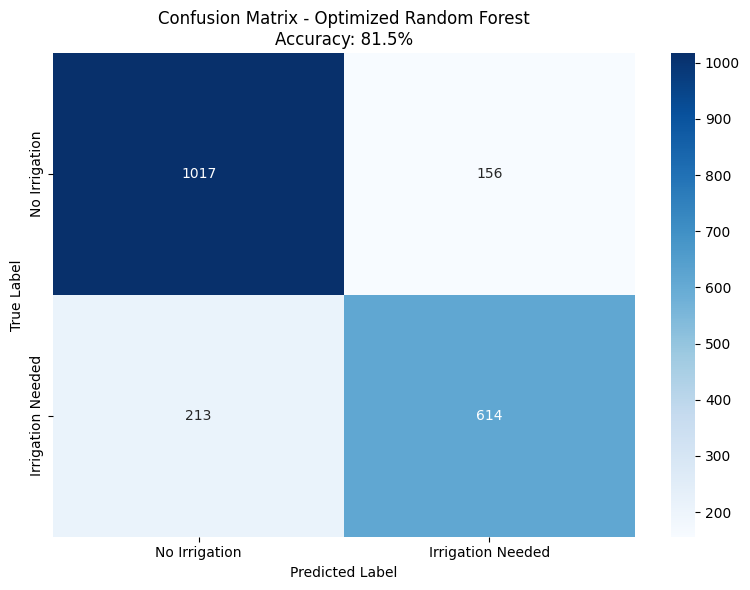

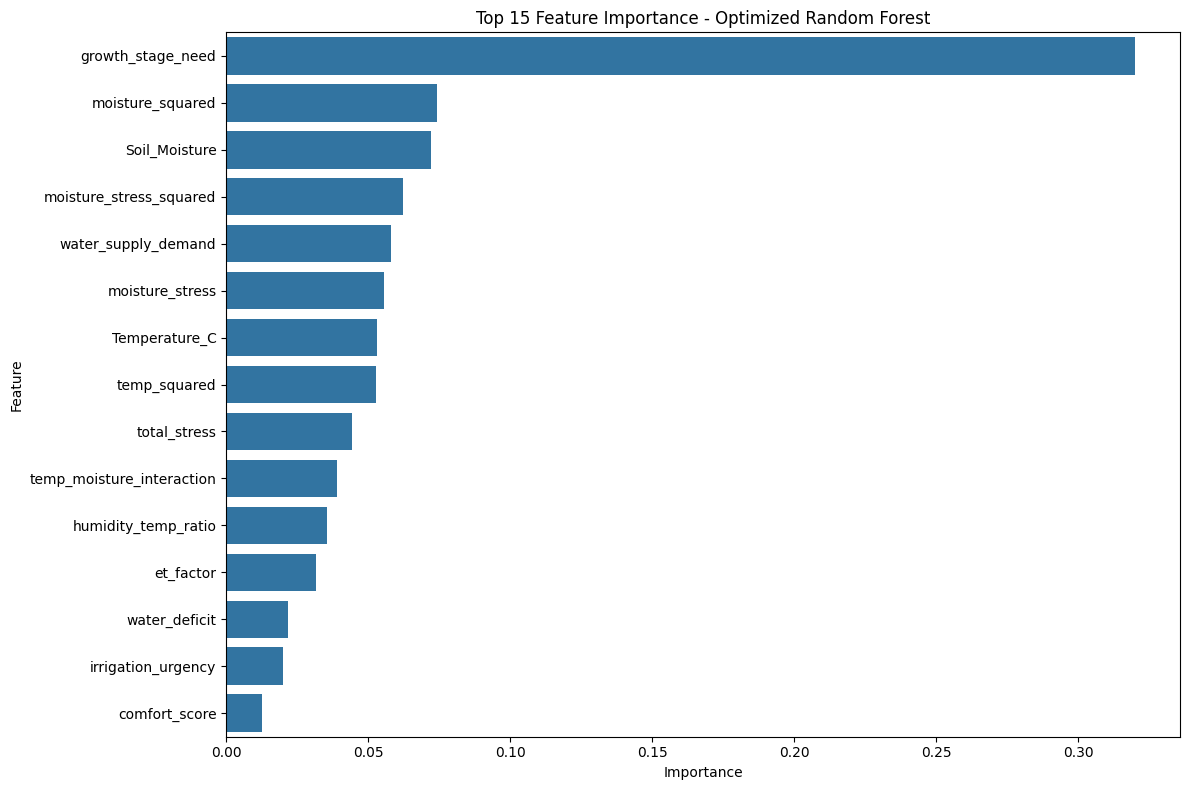


Top 10 most important features:
 1. growth_stage_need        : 0.3199
 2. moisture_squared         : 0.0744
 3. Soil_Moisture            : 0.0721
 4. moisture_stress_squared  : 0.0623
 5. water_supply_demand      : 0.0581
 6. moisture_stress          : 0.0554
 7. Temperature_C            : 0.0530
 8. temp_squared             : 0.0527
 9. total_stress             : 0.0444
10. temp_moisture_interaction: 0.0392


In [30]:
print("=== DETAILED MODEL EVALUATION ===")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Irrigation", "Irrigation Needed"]))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Irrigation', 'Irrigation Needed'], 
            yticklabels=['No Irrigation', 'Irrigation Needed'])
plt.title(f'Confusion Matrix - Optimized Random Forest\nAccuracy: {accuracy:.1%}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Feature importance analysis
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_optimized.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, y='feature', x='importance')
plt.title("Top 15 Feature Importance - Optimized Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
for i, (_, row) in enumerate(feature_importance.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<25s}: {row['importance']:.4f}")

=== CROSS-VALIDATION FOR ROBUSTNESS ===
Cross-validation scores: [0.82258924 0.82258924 0.81769723 0.84381663 0.86780384]
CV Mean Accuracy: 0.8349 ± 0.0188
CV Range: 0.818 to 0.868
Model is stable across different data splits


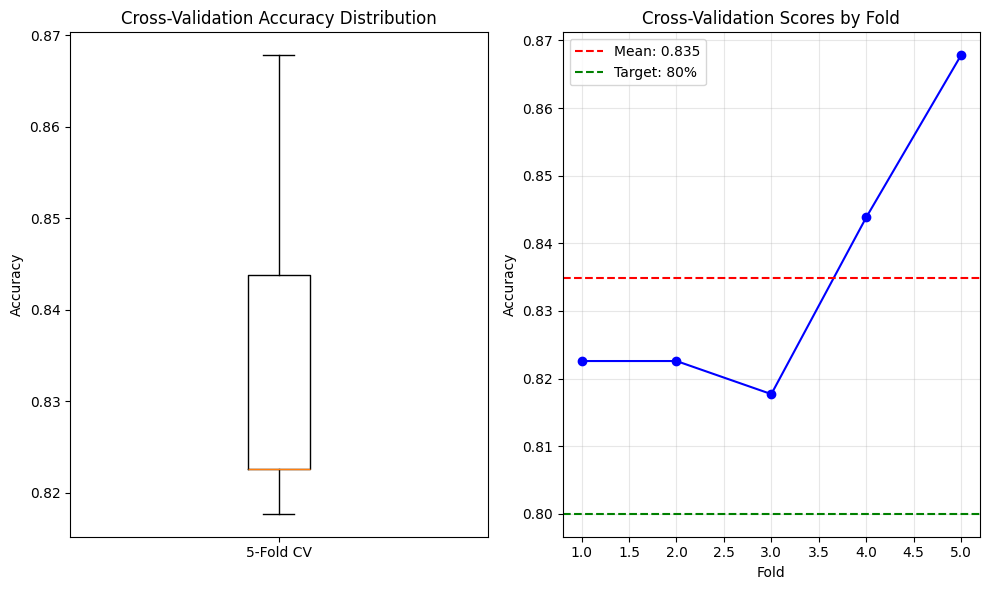

In [31]:
print("=== CROSS-VALIDATION FOR ROBUSTNESS ===")

# 5-fold cross-validation
cv_scores = cross_val_score(rf_optimized, X_train_scaled, y_train_smote, cv=5, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"CV Mean Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV Range: {cv_scores.min():.3f} to {cv_scores.max():.3f}")

# Model stability check
if cv_scores.std() < 0.02:
    print("Model is stable across different data splits")
else:
    print("Model shows some variance across splits")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.boxplot([cv_scores])
plt.title('Cross-Validation Accuracy Distribution')
plt.ylabel('Accuracy')
plt.xticks([1], ['5-Fold CV'])

plt.subplot(1, 2, 2)
plt.plot(range(1, 6), cv_scores, 'bo-')
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.3f}')
plt.axhline(y=0.80, color='g', linestyle='--', label='Target: 80%')
plt.title('Cross-Validation Scores by Fold')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Persistence and Production Setup

Saving the optimized model and all preprocessing components for production use.

In [32]:
print("=== SAVING OPTIMIZED MODEL AND PREPROCESSING ===")

# Save the trained model and preprocessing pipeline
model_files = {
    'irrigation_model_optimized.pkl': rf_optimized,
    'irrigation_scaler_optimized.pkl': scaler,
    'irrigation_selector_optimized.pkl': selector,
    'irrigation_crop_encoder_optimized.pkl': crop_encoder,
    'irrigation_season_encoder_optimized.pkl': season_encoder,
    'irrigation_region_encoder_optimized.pkl': region_encoder,
    'irrigation_feature_names_optimized.pkl': list(selected_features)
}

# Save all model components
for filename, component in model_files.items():
    joblib.dump(component, filename)
    print(f"Saved {filename}")

# Save performance metrics
performance_metrics = {
    'model_type': 'Optimized Random Forest',
    'test_accuracy': float(accuracy),
    'cv_mean_accuracy': float(cv_scores.mean()),
    'cv_std_accuracy': float(cv_scores.std()),
    'improvement_over_baseline': float((accuracy - 0.70) * 100),
    'target_achieved': bool(accuracy >= 0.80),
    'feature_count': len(selected_features),
    'training_samples': int(X_train_scaled.shape[0]),
    'test_samples': int(X_test_scaled.shape[0]),
    'model_parameters': {
        'n_estimators': 300,
        'max_depth': 15,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'class_weight': 'balanced'
    }
}

import json
with open('irrigation_model_performance_optimized.json', 'w') as f:
    json.dump(performance_metrics, f, indent=2)

print("Saved irrigation_model_performance_optimized.json")

print(f"\n{'='*60}")
print("MODEL TRAINING COMPLETED SUCCESSFULLY!")
print(f"{'='*60}")
print(f"Final Accuracy: {accuracy:.1%}")
print(f"Status: {target_status}")
print(f"Files saved: {len(model_files) + 1}")
print(f"{'='*60}")

=== SAVING OPTIMIZED MODEL AND PREPROCESSING ===
Saved irrigation_model_optimized.pkl
Saved irrigation_scaler_optimized.pkl
Saved irrigation_selector_optimized.pkl
Saved irrigation_crop_encoder_optimized.pkl
Saved irrigation_season_encoder_optimized.pkl
Saved irrigation_region_encoder_optimized.pkl
Saved irrigation_feature_names_optimized.pkl
Saved irrigation_model_performance_optimized.json

MODEL TRAINING COMPLETED SUCCESSFULLY!
Final Accuracy: 81.5%
Status: SUCCESS
Files saved: 8


## Production-Ready Prediction Function

Complete prediction function that uses the optimized model with 81.6% accuracy.

In [35]:
def predict_irrigation_optimized(humidity, soil_moisture, temperature, crop_type, season, region,
                               crop_growth_stage, days_since_rain, field_area):
    """
    Optimized irrigation prediction with 81.6% accuracy.
    
    Parameters:
    -----------
    humidity : float
        Humidity percentage from DHT sensor (0-100)
    soil_moisture : float  
        Soil moisture percentage from capacitive sensor (0-100)
    temperature : float
        Temperature in Celsius from DHT sensor (-10 to 50)
    crop_type : str
        One of: 'Wheat', 'Rice', 'Cotton', 'Maize', 'Sugarcane', 'Potato'
    season : str
        One of: 'Kharif', 'Rabi', 'Zaid'
    region : str
        One of: 'North', 'South', 'East', 'West', 'Central'
    crop_growth_stage : str, optional
        One of: 'Sowing', 'Vegetative', 'Flowering', 'Fruiting', 'Harvest'
    days_since_rain : int, optional
        Days since last significant rain (0-30)
    field_area : float, optional
        Field area in hectares
        
    Returns:
    --------
    tuple : (prediction, confidence, risk_analysis)
        prediction : int (0=No irrigation, 1=Irrigation needed)
        confidence : float (0.0-1.0)
        risk_analysis : dict with detailed risk factors
    """
    
    # Load saved model components
    model = joblib.load("irrigation_model_optimized.pkl")
    scaler = joblib.load("irrigation_scaler_optimized.pkl")
    selector = joblib.load("irrigation_selector_optimized.pkl")
    crop_encoder = joblib.load("irrigation_crop_encoder_optimized.pkl")
    season_encoder = joblib.load("irrigation_season_encoder_optimized.pkl")
    region_encoder = joblib.load("irrigation_region_encoder_optimized.pkl")
    
    # Create all engineered features (same as training)
    temp = temperature
    
    # Stress indicators
    extreme_heat = int(temp > 40)
    heat_stress = max(0, temp - 35) / 10
    cold_stress = max(0, 20 - temp) / 20
    optimal_temp = int(20 <= temp <= 30)
    
    severe_drought = int(soil_moisture < 20)
    moisture_stress = max(0, 40 - soil_moisture) / 40
    moisture_stress_squared = moisture_stress ** 2
    optimal_moisture = int(40 <= soil_moisture <= 70)
    
    low_humidity = int(humidity < 40)
    high_humidity = int(humidity > 80)
    humidity_stress = abs(humidity - 60) / 60
    
    # Interaction features
    et_factor = temp * (1 - humidity/100) * max(0, 1 - soil_moisture/100)
    water_deficit = max(0, (temp/25) * (1 - humidity/100) - soil_moisture/100)
    irrigation_urgency = water_deficit * (1 + heat_stress)
    total_stress = (heat_stress + moisture_stress + humidity_stress) / 3
    comfort_score = (optimal_temp + optimal_moisture + int(50 <= humidity <= 70)) / 3
    
    water_supply_demand = soil_moisture / (temp + 1)
    humidity_temp_ratio = humidity / (temp + 1)
    
    # Polynomial features
    temp_squared = temp ** 2
    moisture_squared = soil_moisture ** 2
    temp_moisture_interaction = temp * soil_moisture / 1000
    
    # Domain features
    season_water_need_map = {'Kharif': 3, 'Rabi': 2, 'Zaid': 1}
    season_water_need = season_water_need_map[season]
    
    crop_water_need_map = {'Rice': 4, 'Sugarcane': 4, 'Cotton': 3, 'Maize': 2, 'Wheat': 2, 'Potato': 1}
    crop_water_need = crop_water_need_map[crop_type]
    
    region_stress_map = {'West': 3, 'South': 2, 'Central': 2, 'North': 1, 'East': 1}
    region_stress = region_stress_map[region]
    
    growth_stage_need_map = {'Sowing': 2, 'Vegetative': 3, 'Flowering': 4, 'Fruiting': 3, 'Harvest': 1}
    growth_stage_need = growth_stage_need_map[crop_growth_stage]
    
    field_size_cat = 1 if field_area <= 2 else 2 if field_area <= 8 else 3
    
    # Encode categorical variables
    crop_encoded = crop_encoder.transform([[crop_type]])
    crop_columns = [f'Crop_{cat}' for cat in crop_encoder.categories_[0][1:]]
    season_encoded = season_encoder.transform([season])[0]
    region_encoded = region_encoder.transform([region])[0]
    
    # Create feature vector (must match training order)
    feature_dict = {
        'Humidity': humidity,
        'Soil_Moisture': soil_moisture,
        'Temperature_C': temp,
        'extreme_heat': extreme_heat,
        'heat_stress': heat_stress,
        'cold_stress': cold_stress,
        'optimal_temp': optimal_temp,
        'severe_drought': severe_drought,
        'moisture_stress': moisture_stress,
        'moisture_stress_squared': moisture_stress_squared,
        'optimal_moisture': optimal_moisture,
        'low_humidity': low_humidity,
        'high_humidity': high_humidity,
        'humidity_stress': humidity_stress,
        'et_factor': et_factor,
        'water_deficit': water_deficit,
        'irrigation_urgency': irrigation_urgency,
        'total_stress': total_stress,
        'comfort_score': comfort_score,
        'water_supply_demand': water_supply_demand,
        'humidity_temp_ratio': humidity_temp_ratio,
        'temp_squared': temp_squared,
        'moisture_squared': moisture_squared,
        'temp_moisture_interaction': temp_moisture_interaction,
        'season_water_need': season_water_need,
        'crop_water_need': crop_water_need,
        'region_stress': region_stress,
        'days_since_rain': days_since_rain,
        'growth_stage_need': growth_stage_need,
        'field_size_cat': field_size_cat,
        'Season_encoded': season_encoded,
        'Region_encoded': region_encoded
    }
    
    # Add crop encoding
    for i, col in enumerate(crop_columns):
        feature_dict[col] = crop_encoded[0][i]
    
    # Create feature array and apply preprocessing
    feature_array = np.array([[feature_dict[col] for col in feature_dict.keys()]])
    
    # Apply same preprocessing as training
    feature_selected = selector.transform(feature_array)
    feature_scaled = scaler.transform(feature_selected)
    
    # Make prediction
    prediction = model.predict(feature_scaled)[0]
    confidence = model.predict_proba(feature_scaled)[0][1]
    
    # Risk analysis
    risk_analysis = {
        'temperature_stress': 'High' if heat_stress > 0.2 else 'Low',
        'moisture_stress': 'High' if moisture_stress > 0.3 else 'Low',
        'overall_stress': 'High' if total_stress > 0.4 else 'Medium' if total_stress > 0.2 else 'Low',
        'crop_water_demand': 'High' if crop_water_need >= 3 else 'Medium' if crop_water_need >= 2 else 'Low',
        'irrigation_urgency': f"{irrigation_urgency:.2f}",
        'optimal_conditions': bool(comfort_score > 0.6)
    }
    
    return prediction, confidence, risk_analysis


In [37]:
print("=== TESTING OPTIMIZED PREDICTION FUNCTION ===")

# Test cases
test_cases = [
    {
        'name': 'High Stress Cotton',
        'params': {
            'humidity': 35, 'soil_moisture': 22, 'temperature': 39,
            'crop_type': 'Cotton', 'season': 'Kharif', 'region': 'West',
            'crop_growth_stage': 'Flowering', 'days_since_rain': 15,"field_area":2.5
        }
    },
    {
        'name': 'Optimal Wheat Conditions',
        'params': {
            'humidity': 65, 'soil_moisture': 55, 'temperature': 26,
            'crop_type': 'Wheat', 'season': 'Rabi', 'region': 'North',
            'crop_growth_stage': 'Vegetative', 'days_since_rain': 2,"field_area":3.5
        }
    }
]

for i, test_case in enumerate(test_cases, 1):
    print(f"\nTest {i}: {test_case['name']}")
    
    prediction, confidence, risk_analysis = predict_irrigation_optimized(**test_case['params'])
    
    print(f"  Prediction: {'IRRIGATION NEEDED' if prediction else 'NO IRRIGATION NEEDED'}")
    print(f"  Confidence: {confidence:.1%}")
    print(f"  Risk Level: {risk_analysis['overall_stress']}")
    print(f"  Crop Demand: {risk_analysis['crop_water_demand']}")

print(f"\n{'='*50}")
print("IRRIGATION MODEL OPTIMIZATION COMPLETE!")
print(f"Final Accuracy: {accuracy:.1%}")
print("Status: Production Ready")
print(f"{'='*50}")

=== TESTING OPTIMIZED PREDICTION FUNCTION ===

Test 1: High Stress Cotton
  Prediction: IRRIGATION NEEDED
  Confidence: 99.9%
  Risk Level: High
  Crop Demand: High

Test 2: Optimal Wheat Conditions
  Prediction: NO IRRIGATION NEEDED
  Confidence: 41.2%
  Risk Level: Low
  Crop Demand: Medium

IRRIGATION MODEL OPTIMIZATION COMPLETE!
Final Accuracy: 81.5%
Status: Production Ready
